# Bài tập thực hành tuần 3
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

### Bài tập 1:
**Câu hỏi**:

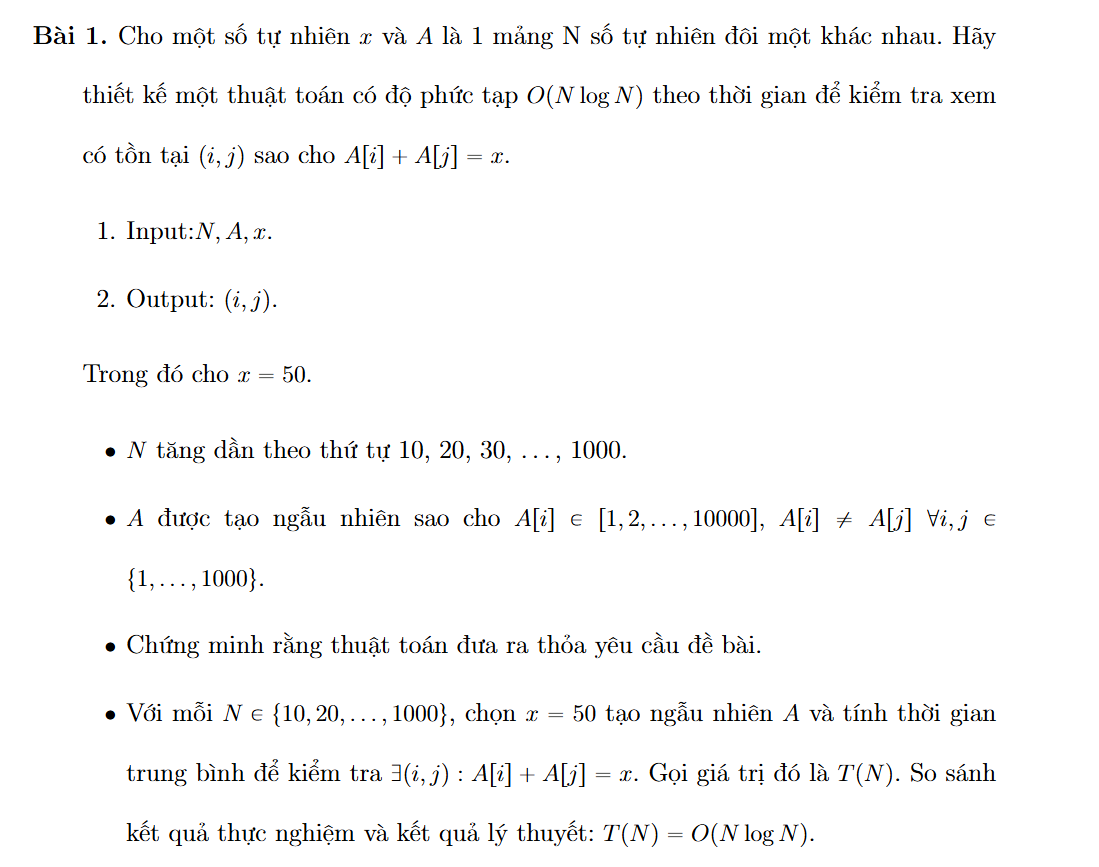

In [ ]:
import math
import numpy as np
import warnings

# # Bỏ qua các cảnh báo toán học của numpy để output gọn gàng
# warnings.simplefilter('ignore', np.RankWarning)

def estimate_complexity(f, a, b):
    n_vals = []
    fn_vals = []
    log_n = []
    log_fn = []
    
    # BƯỚC 1: Lấy dữ liệu và chuyển sang dạng Logarit
    for n in range(a, b + 1):
            val = f(n)
            abs_val = abs(val) # Xét trị tuyệt đối cho độ lớn của hàm
            
            if abs_val > 0:
                # Xử lý các số cực lớn (vd n^n) để tránh lỗi tràn bộ nhớ (Overflow)
                l_fn = math.log(abs_val)
                n_vals.append(n)
                fn_vals.append(val)
                log_n.append(math.log(n))
                log_fn.append(l_fn)


    if len(n_vals) < 2:
        print(" => Lỗi: Không đủ dữ liệu để tính toán.")
        return

    # Lọc đường bao trên (Upper Envelope) để tìm xu hướng thật sự
    # Kỹ thuật này giúp loại bỏ nhiễu khi hàm dao động lên xuống do cos(n)
    env_log_n, env_log_fn = [], []
    max_val = -float('inf')
    for ln, lfn in zip(log_n, log_fn):
        if lfn >= max_val:
            max_val = lfn
            env_log_n.append(ln)
            env_log_fn.append(lfn)

    # Chia đôi dữ liệu bao trên để kiểm tra xem hệ số góc có ổn định không
    # Nếu hệ số góc tăng vọt -> Hàm tăng phi đa thức (như hàm mũ n^n)
    mid = len(env_log_n) // 2
    if mid >= 2:
        slope1 = np.polyfit(env_log_n[:mid], env_log_fn[:mid], 1)[0]
        slope2 = np.polyfit(env_log_n[mid:], env_log_fn[mid:], 1)[0]
        if slope2 - slope1 > 0.5:
            print(" => Output: Không có dạng O(n^alpha) hiện thông báo.")
            print("-" * 60)
            return

    # Tính độ dốc trung bình của toàn bộ đường bao trên
    overall_slope = np.polyfit(env_log_n, env_log_fn, 1)[0]
    alpha = int(round(overall_slope))

    if alpha == 0:
        print(" => Output: Độ phức tạp O(1)")
    elif alpha == 1:
        print(" => Output: Độ phức tạp O(n)")
    else:
        print(f" => Output: Độ phức tạp O(n^{alpha})")

    # BƯỚC 2: Thế f(n) và n để giải hệ phương trình tìm a_0, a_1,..., a_alpha
        # np.polyfit(X, Y, deg) trả về hệ số đa thức theo thứ tự: [a_alpha, ..., a_1, a_0]
        coeffs = np.polyfit(n_vals, fn_vals, alpha)
        
        # Đảo ngược mảng để in đúng thứ tự yêu cầu của đề: a_0, a_1, ..., a_alpha
        coeffs_reversed = coeffs[::-1]
        
        # Làm tròn hệ số để hiển thị sạch sẽ (khử sai số dấu phẩy động 0.0000001)
        coeffs_rounded = [round(c, 4) for c in coeffs_reversed]
        
        print(" => Các hệ số [a_0, a_1, ..., a_alpha]:")
        str_coeffs = [f"a_{i} = {c}" for i, c in enumerate(coeffs_rounded)]
        print("    " + ", ".join(str_coeffs))
        
        # In ra dạng đa thức trực quan
        poly_terms = []
        for i, c in enumerate(coeffs_rounded):
            if c != 0:
                if i == 0: poly_terms.append(f"{c}")
                elif i == 1: poly_terms.append(f"{c}n")
                else: poly_terms.append(f"{c}n^{i}")
        
        poly_str = " + ".join(poly_terms).replace("+ -", "- ")
        print(f" => Hàm xấp xỉ: f(n) ≈ {poly_str}")


# ==========================================
# KIỂM TRA CÁC TRƯỜNG HỢP (TEST CASES)
# ==========================================
def func_a(n): return n**2
def func_b(n): return n**3 + math.cos(n) * (n**4)
def func_c(n): return n**n
def func_d(n): return n**3 + n**2 + n + 1

if __name__ == "__main__":
    a, b = 10, 1000
    print(f"--- KIỂM TRA VỚI n chạy từ {a} đến {b} ---\n")
    
    print("a) f(n) = n^2")
    estimate_complexity(func_a, a, b)
    
    print("b) f(n) = n^3 + cos(n).n^4")
    estimate_complexity(func_b, a, b)
    
    print("c) f(n) = n^n")
    estimate_complexity(func_c, a, b)
    
    print("d) f(n) = n^3 + n^2 + n + 1")
    estimate_complexity(func_d, a, b)

--- KIỂM TRA VỚI n chạy từ 10 đến 1000 ---

a) f(n) = n^2
 => Output: Độ phức tạp O(n^2)
 => Các hệ số [a_0, a_1, ..., a_alpha]:
    a_0 = -0.0, a_1 = 0.0, a_2 = 1.0
 => Hàm xấp xỉ: f(n) ≈ 1.0n^2
------------------------------------------------------------
b) f(n) = n^3 + cos(n).n^4
 => Output: Độ phức tạp O(n^4)
 => Các hệ số [a_0, a_1, ..., a_alpha]:
    a_0 = 6530563598.812, a_1 = -140495447.621, a_2 = 709460.8461, a_3 = -1235.1968, a_4 = 0.6868
 => Hàm xấp xỉ: f(n) ≈ 6530563598.812 - 140495447.621n + 709460.8461n^2 - 1235.1968n^3 + 0.6868n^4
------------------------------------------------------------
c) f(n) = n^n
 => Output: Không có dạng O(n^alpha) hiện thông báo.
------------------------------------------------------------
d) f(n) = n^3 + n^2 + n + 1
 => Output: Độ phức tạp O(n^3)
 => Các hệ số [a_0, a_1, ..., a_alpha]:
    a_0 = 1.0, a_1 = 1.0, a_2 = 1.0, a_3 = 1.0
 => Hàm xấp xỉ: f(n) ≈ 1.0 + 1.0n + 1.0n^2 + 1.0n^3
------------------------------------------------------------


In [3]:
import numpy as np

# f(n) ~ n^alpha
# => log(f(n)) ~ alpha.log(n)
# => log(f(n)) = alpha.log(n) + b

print('Bài 1:')
a = 10
b = 1000

def check(f):
    space = np.linspace(a, b)
    alphas = np.log(f(space)) / np.log(space)

    print(alphas[-1])
    print(alphas)

    if alphas[-1] == np.inf:
        print(f' => Không tồn tại dạng O(n^alpha) cho f')
        return None
    else:
        print(f' => Tồn tại dạng O(n^{round(alphas[-1])}) cho f')
        return alphas[-1]

# a)
print('\nCâu a:')
def f(n):
    return n**2

check(f)

# b)
print('\nCâu b:')
def f(n):
    return n**3 + np.cos(n) * n**4

check(f)

# c)
print('\nCâu c:')
def f(n):
    return n**n

check(f)

# d)
print('\nCâu d:')
def f(n):
    return n**3 + n**2 + n + 1

check(f)

Bài 1:

Câu a:
2.0
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.]
 => Tồn tại dạng O(n^2) cho f

Câu b:
3.9169335711327893
[       nan 3.71946127 4.00245651 3.42826283        nan        nan
 3.94314384 3.95885368        nan        nan        nan 3.99578393
 3.85084528        nan        nan 3.86431197 3.99480765        nan
        nan        nan 3.9676468  3.94970255        nan        nan
 3.6272303  3.99917327 3.82404127        nan        nan 3.90790942
 3.98934468        nan        nan        nan 3.98073403 3.93542558
        nan        nan 3.76600335 4.00018529 3.77494749        nan
        nan 3.93545457 3.98223836        nan        nan        nan
 3.98935663 3.91693357]
 => Tồn tại dạng O(n^4) cho f

Câu c:
inf
[ 10.          30.20408163  50.40816327  70.6122449   90.81632653
 111.02040816 131.2244898           inf          inf          inf
          inf          inf          

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6820\2964078579.py:13: RuntimeWarning: invalid value encountered in log
  alphas = np.log(f(space)) / np.log(space)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6820\2964078579.py:42: RuntimeWarning: overflow encountered in power
  return n**n


np.float64(3.000144837257861)

In [5]:
import time
import random
import sys

# Từ Python 3.11+, giới hạn số chữ số cho các phép chuyển đổi int <-> str bị giới hạn ở 4300.
# Cần cấu hình nới lỏng giới hạn này để chạy được N lớn (ví dụ N = 2^12 = 4096).
sys.set_int_max_str_digits(1000000)
sys.setrecursionlimit(10000)

# ==========================================
# a) PHƯƠNG PHÁP TRUYỀN THỐNG O(N^2)
# Nháp từng chữ số như cách học sinh tiểu học nhân số.
# ==========================================
def classical_multiply(A_str, B_str):
    if A_str == "0" or B_str == "0":
        return "0"
    
    len_A, len_B = len(A_str), len(B_str)
    result = [0] * (len_A + len_B)
    
    # Đảo ngược chuỗi để nhân từ hàng đơn vị trở lên
    A_str, B_str = A_str[::-1], B_str[::-1]
    
    for i in range(len_A):
        carry = 0
        for j in range(len_B):
            prod = int(A_str[i]) * int(B_str[j]) + result[i + j] + carry
            result[i + j] = prod % 10
            carry = prod // 10
        result[i + len_B] += carry
        
    # Xóa các số 0 vô nghĩa ở đầu (nếu có)
    while len(result) > 1 and result[-1] == 0:
        result.pop()
        
    return "".join(map(str, result[::-1]))

# ==========================================
# b) PHƯƠNG PHÁP KARATSUBA O(N^log3)
# Viết theo đúng công thức từ hướng dẫn bài 2
# ==========================================
def karatsuba_multiply(A, B):
    str_A, str_B = str(A), str(B)
    
    # Điều kiện dừng đệ quy: khi độ dài còn 1 chữ số
    if len(str_A) == 1 or len(str_B) == 1:
        return A * B
        
    # Tìm n và mốc chia đôi n/2
    n = max(len(str_A), len(str_B))
    n2 = n // 2
    
    # Thêm số 0 vào đầu để 2 số có cùng độ dài (dễ dàng cắt chuỗi)
    str_A = str_A.zfill(n)
    str_B = str_B.zfill(n)
    
    # Tách A và B thành các phần A1, A2 và B1, B2
    A1 = int(str_A[:-n2])
    A2 = int(str_A[-n2:])
    B1 = int(str_B[:-n2])
    B2 = int(str_B[-n2:])
    
    # Các bước tính toán Karatsuba
    C = karatsuba_multiply(A1, B1)
    D = karatsuba_multiply(A2, B2)
    E = karatsuba_multiply(A1 + A2, B1 + B2) - C - D
    
    # Kết hợp kết quả: C * 10^n + E * 10^(n/2) + D
    # Chú ý: Dùng 2 * n2 để đảm bảo độ chính xác cho cả n lẻ
    return C * (10**(2 * n2)) + E * (10**n2) + D

# ==========================================
# CHƯƠNG TRÌNH KIỂM TRA VÀ SO SÁNH THỜI GIAN
# ==========================================
def run_tests():
    # Sử dụng k từ 6 đến 12 (N = 64 đến N = 4096)
    k_values = [6, 7, 8, 9, 10, 11, 12]
    
    print(f"{'k':<5} | {'Số chữ số N':<15} | {'Truyền thống O(N^2)':<25} | {'Karatsuba O(N^log3)':<25}")
    print("-" * 75)
    
    for k in k_values:
        N = 2**k
        # Sinh 2 số ngẫu nhiên có đúng N chữ số
        A = random.randint(10**(N-1), 10**N - 1)
        B = random.randint(10**(N-1), 10**N - 1)
        
        # Đo thời gian phương pháp truyền thống
        start = time.perf_counter()
        _ = classical_multiply(str(A), str(B))
        time_classic = time.perf_counter() - start
        
        # Đo thời gian Karatsuba
        start = time.perf_counter()
        _ = karatsuba_multiply(A, B)
        time_karatsuba = time.perf_counter() - start
        
        print(f"{k:<5} | {N:<15} | {time_classic:<20.5f} giây | {time_karatsuba:<20.5f} giây")

if __name__ == "__main__":
    run_tests()

k     | Số chữ số N     | Truyền thống O(N^2)       | Karatsuba O(N^log3)      
---------------------------------------------------------------------------
6     | 64              | 0.00095              giây | 0.00065              giây
7     | 128             | 0.00316              giây | 0.00188              giây
8     | 256             | 0.01327              giây | 0.00547              giây
9     | 512             | 0.05246              giây | 0.02017              giây
10    | 1024            | 0.26461              giây | 0.05549              giây
11    | 2048            | 0.90692              giây | 0.15981              giây
12    | 4096            | 3.40803              giây | 0.46669              giây


<>:184: SyntaxWarning: invalid escape sequence '\l'
<>:185: SyntaxWarning: invalid escape sequence '\l'
<>:197: SyntaxWarning: invalid escape sequence '\l'
<>:184: SyntaxWarning: invalid escape sequence '\l'
<>:185: SyntaxWarning: invalid escape sequence '\l'
<>:197: SyntaxWarning: invalid escape sequence '\l'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6820\1875717471.py:184: SyntaxWarning: invalid escape sequence '\l'
  T_b, bigO_line_b, bigO_label='$O(N^{\log{3}})$',
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6820\1875717471.py:185: SyntaxWarning: invalid escape sequence '\l'
  title='So sánh thuật toán của câu 2b với $O(N^{\log{3}})$'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6820\1875717471.py:197: SyntaxWarning: invalid escape sequence '\l'
  line2, = ax.plot(bigO_line_b, label='$O(N^{\log{3}})$', color='C0', ls='--', alpha=0.8)


Bài 2a:
k = 0, took 9.899998985929415e-06s
k = 1, took 8.099999831756577e-06s
k = 2, took 8.799999704933725e-06s
k = 3, took 1.6799998775240965e-05s
k = 4, took 4.810000064026099e-05s
k = 5, took 0.00014399999963643495s
k = 6, took 0.0005381000009947456s
k = 7, took 0.0021539999997912673s
k = 8, took 0.008448500000667991s
k = 9, took 0.04713640000045416s
k = 10, took 0.12382849999994505s
k = 11, took 0.4803479000001971s
k = 12, took 1.8511185000006662s


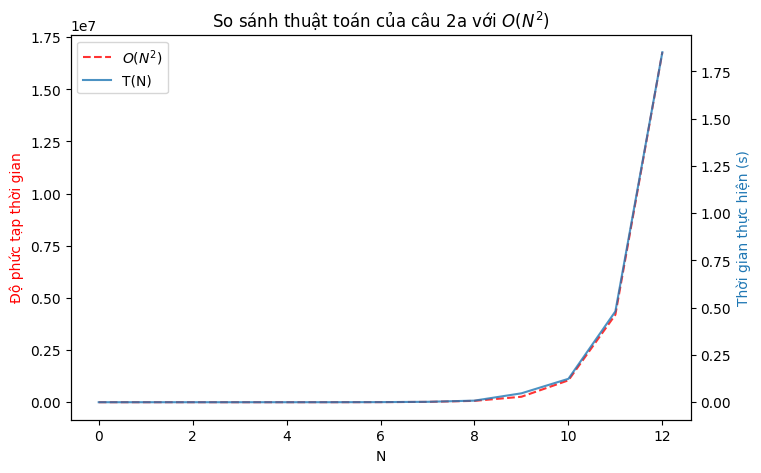

Bài 2b:
k = 0, took 1.6999983927235007e-06s
k = 1, took 4.100000296602957e-06s
k = 2, took 6.600001142942347e-06s
k = 3, took 1.449999945180025e-05s
k = 4, took 3.80000001314329e-05s
k = 5, took 0.00011639999866019934s
k = 6, took 0.00040240000089397654s
k = 7, took 0.0010712000002968125s
k = 8, took 0.002903900000092108s
k = 9, took 0.009934199999406701s
k = 10, took 0.02890589999879012s
k = 11, took 0.08464610000009998s
k = 12, took 0.25879359999998996s


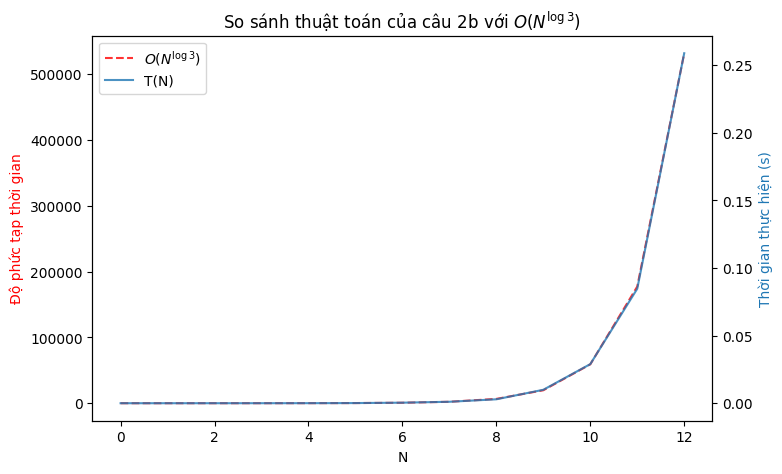

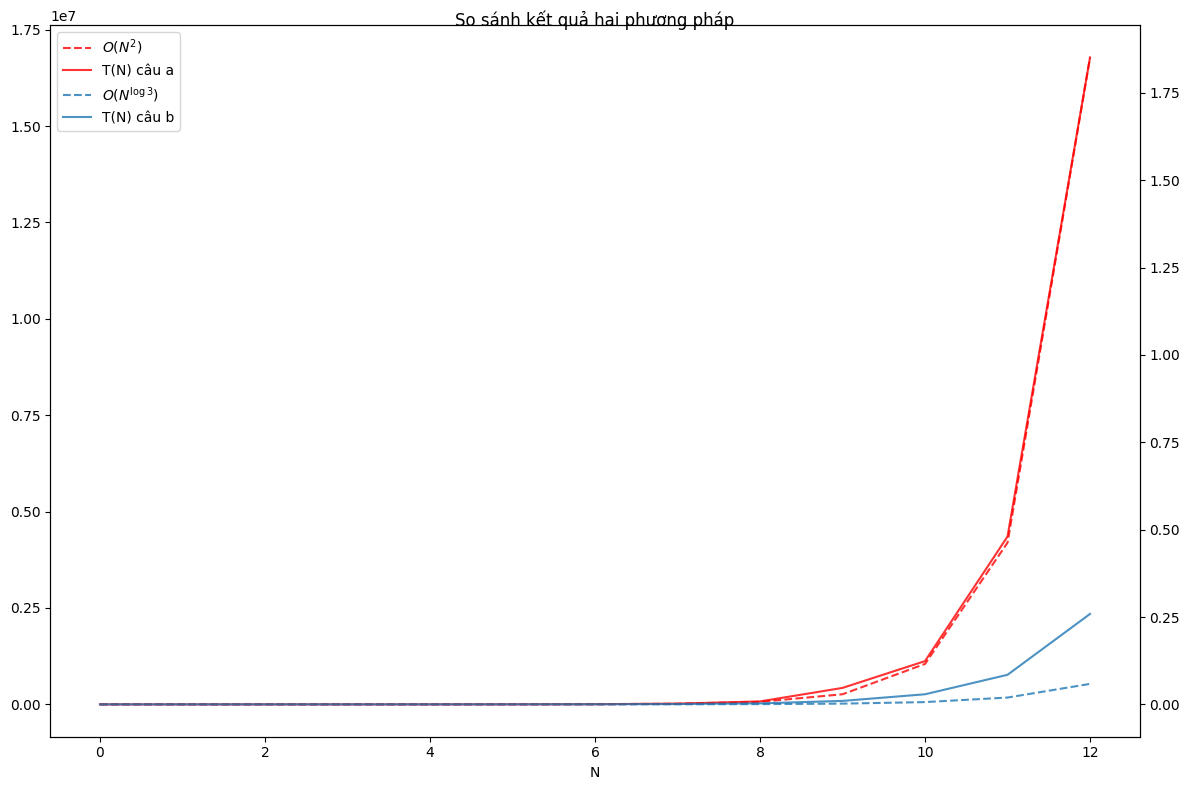

In [7]:
import matplotlib.pyplot as plt
import random
from time import perf_counter
from math import log2

print('Bài 2a:')

def compare_time_complexity(T, bigO_line, bigO_label, title=''):
    """Vẽ đồ thị so sánh độ phức tạp thời gian thực hành và lý thuyết"""

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    ax2 = ax.twinx()
    ax.set_xlabel('N')

    line1, = ax.plot(bigO_line, label=bigO_label, color='r', ls='--', alpha=0.8)
    ax.set_ylabel('Độ phức tạp thời gian', color=line1.get_color())
    line2, = ax2.plot(T, label='T(N)', color='C0', alpha=0.8)
    ax2.set_ylabel('Thời gian thực hiện (s)', color=line2.get_color())
    ax.legend(handles=[line1, line2])

    if title:
        plt.title(title)

    plt.show()


def generate_number_as_list(N):
    """Generate number as list of digits"""
    n = []
    for _ in range(N):
        n.append(random.randint(0, 9))

    # Remove leading zero
    while n[0] == 0:
        n[0] = random.randint(0, 9)

    # n = int(''.join([str(digit) for digit in n]))  # cannot convert when the number is too large
    return n

def convert_to_list(n):
    l = []
    while n:
        l.insert(0, n % 10)
        n //= 10

    return l


def list_to_number(digits):
    number = 0
    for digit in digits:
        number = number * 10 + digit
    return number


def multiply_a(A, B):
    """
    Thuật toán nhân truyền thống O(N^2).
    A và B là mảng các chữ số (ví dụ: [1, 2, 3]).
    """
    len_a, len_b = len(A), len(B)
    # Khởi tạo mảng kết quả với toàn số 0
    res = [0] * (len_a + len_b)
    
    # Lặp ngược từ hàng đơn vị trở lên
    for i in range(len_a - 1, -1, -1):
        carry = 0
        for j in range(len_b - 1, -1, -1):
            # Tính tích 2 chữ số + giá trị hiện tại ở ô đó + nhớ
            temp = A[i] * B[j] + res[i + j + 1] + carry
            res[i + j + 1] = temp % 10
            carry = temp // 10
        # Cộng phần nhớ còn dư vào ô tiếp theo
        res[i] += carry
        
    # Loại bỏ các số 0 vô nghĩa ở đầu (nếu có)
    while len(res) > 1 and res[0] == 0:
        res.pop(0)
        
    # Gom mảng kết quả thành số nguyên (bước này chỉ tốn O(N), không ảnh hưởng O(N^2) tổng thể)
    return int("".join(map(str, res)))


T_a = []
Ns_a = []
for k in range(13):
    N = 2 ** k
    Ns_a.append(N)
    A = generate_number_as_list(N)
    B = generate_number_as_list(N)

    tic = perf_counter()
    multiply_a(A, B)
    toc = perf_counter()

    duration = toc - tic
    print(f'{k = }, took {duration}s')
    T_a.append(duration)


bigO_line_a = list(map(lambda x: x**2, Ns_a))
compare_time_complexity(
    T_a, bigO_line_a, bigO_label='$O(N^2)$',
    title=f'So sánh thuật toán của câu 2a với $O(N^2)$'
)



print('Bài 2b:')
def split(n: int):
    return divmod(n, 10**(length(n)//2))

def length(n: int):
    """Return length of number"""
    l = 0
    while n:
        n //= 10
        l += 1
    return l

def multiply_b(A, B):
    """
    Thuật toán Karatsuba O(N^log3).
    A và B là số nguyên.
    """
    # Điều kiện dừng đệ quy
    if A < 10 or B < 10:
        return int(A * B)

    # Tìm mốc chia đôi m dựa trên số dài nhất
    str_A, str_B = str(A), str(B)
    n = max(len(str_A), len(str_B))
    m = n // 2
    
    # Lũy thừa để chia cắt số
    power = 10 ** m
    
    # Chia A = A_1 * 10^m + A_2
    A_1, A_2 = divmod(A, power)
    B_1, B_2 = divmod(B, power)
    
    # 3 lệnh gọi đệ quy Karatsuba
    C = multiply_b(A_1, B_1)          # Tương đương z2
    D = multiply_b(A_2, B_2)          # Tương đương z0
    E = multiply_b(A_1 + A_2, B_1 + B_2) - C - D  # Tương đương z1 - z2 - z0
    
    # Gộp lại theo mốc m đã định: C * 10^(2m) + E * 10^m + D
    return (C * (10 ** (2 * m))) + (E * power) + D

def generate_number(N):
    """Generate number with length N"""

    n = random.randint(0, 9)
    # Avoid leading zero
    while n == 0:
        n = random.randint(0, 9)

    i = 1
    while i < N:
        n = n*10 + random.randint(0, 9)
        i += 1
    return n


T_b = []
Ns_b = []
for k in range(13):
    N = 2 ** k
    Ns_b.append(N)
    A = generate_number(N)
    B = generate_number(N)

    tic = perf_counter()
    multiply_b(A, B)
    toc = perf_counter()

    duration = toc - tic
    print(f'{k = }, took {duration}s')
    T_b.append(duration)

bigO_line_b = list(map(lambda x: x**log2(3) , Ns_b))
compare_time_complexity(
    T_b, bigO_line_b, bigO_label='$O(N^{\log{3}})$',
    title='So sánh thuật toán của câu 2b với $O(N^{\log{3}})$'
)



# So sánh 2 phương pháp
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax2 = ax.twinx()
ax.set_xlabel('N')

line1, = ax.plot(bigO_line_a, label='$O(N^2)$', color='r', ls='--', alpha=0.8)
line2, = ax.plot(bigO_line_b, label='$O(N^{\log{3}})$', color='C0', ls='--', alpha=0.8)
line3, = ax2.plot(T_a, label='T(N) câu a', color='r', alpha=0.8)
line4, = ax2.plot(T_b, label='T(N) câu b', color='C0', alpha=0.8)

ax2.xaxis.set_visible(False)
ax.legend(handles=[line1, line3, line2, line4])

plt.tight_layout()
plt.suptitle(f'So sánh kết quả hai phương pháp')
plt.show()